<a href="https://colab.research.google.com/github/anhndt0310-jpg/vietnamese-cyberbullying-detection/blob/main/vietnamese_cyberbullying_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers torch pandas numpy scikit-learn

# lấy file từ drive
from google.colab import drive
drive.mount('/content/drive')

# kiểm tra GPU tránh crashed
import torch
print("Check: ", torch.cuda.is_available())

Mounted at /content/drive
GPU đang sẵn sàng: True


In [6]:
import pandas as pd
#Đường dẫn file từ drive
train_path = '/content/drive/MyDrive/df_train_clean.csv'
test_path = '/content/drive/MyDrive/df_test_clean.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Check thông tin xem đã được nạp thành công chưa
print("Số dòng trong tập Train:", len(train_df))
print("Các cột có trong file:", train_df.columns.tolist())

# check 3 dòng đầu
print("\n[3 dòng đầu tập train]")
print(train_df.head(3))

Số dòng trong tập Train: 7000
Các cột có trong file: ['Unnamed: 0', 'content', 'Constructiveness', 'Toxicity', 'Title', 'Topic', 'content_clean']

--- 3 dòng đầu của tập Train ---
   Unnamed: 0                                            content  \
0        6326                               Thật tuyệt vời...!!!   
1        7835  mỹ đã tuột dốc quá nhiều rồi, giờ muốn vực dậy...   
2        4690  tôi thấy người lái xe hơi bấm còi mới là người...   

   Constructiveness  Toxicity  \
0                 0         0   
1                 1         0   
2                 1         1   

                                               Title     Topic  \
0  Những 'bước tiến diệu kỳ' của Trúc Nhi - Diệu Nhi   SucKhoe   
1  Hình tượng Mỹ sụp đổ trong lòng người dân thế ...   TheGioi   
2         Cả trăm người đạp xe thể dục bịt kín đường  OtoXemay   

                                       content_clean  
0                               Thật tuyệt vời...!!!  
1  mỹ đã tuột dốc quá nhiều rồi, giờ mu

In [4]:
# Trích xuất cho tập Train
print("[Đang trích xuất đặc trưng cho tập Train]")
X_train_emb = get_phobert_embeddings(train_df['content_clean'].fillna('').tolist())
y_train = train_df['Toxicity'].values

# Trích xuất cho tập Test
print("\n[Đang trích xuất đặc trưng cho tập Test]")
X_test_emb = get_phobert_embeddings(test_df['content_clean'].fillna('').tolist())
y_test = test_df['Toxicity'].values

print("\n\nĐÃ XONG! DỮ LIỆU ĐÃ SẴN SÀNG ĐỂ HUẤN LUYỆN")

--- Đang trích xuất đặc trưng cho tập Train (7000 câu) ---


100%|██████████| 438/438 [00:37<00:00, 11.59it/s]



--- Đang trích xuất đặc trưng cho tập Test ---


100%|██████████| 63/63 [00:05<00:00, 11.98it/s]


Hoàn tất! Dữ liệu đã sẵn sàng để huấn luyện.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Khởi tạo và huấn luyện lại với tên biến riêng biệt
lr_final = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

print("Đang huấn luyện Logistic Regression...")
lr_final.fit(X_train_emb, y_train)

# Lưu mô hình này vào Drive để đảm bảo file pkl là mô hình ML, không phải Transformer
joblib.dump(lr_final, '/content/drive/MyDrive/phobert_logreg_model.pkl')

# Dự đoán trên tập Test
y_pred_lr = lr_final.predict(X_test_emb)

print("\n=== KẾT QUẢ LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))

Đang huấn luyện Logistic Regression...

=== KẾT QUẢ LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       890
           1       0.28      0.61      0.39       110

    accuracy                           0.79      1000
   macro avg       0.61      0.71      0.63      1000
weighted avg       0.87      0.79      0.82      1000



Thử các classifier khác

In [26]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Random forest
rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_emb, y_train)
y_pred_rf = rf_model.predict(X_test_emb)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # Xử lý imbalanced
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_emb, y_train)
y_pred_xgb = xgb_model.predict(X_test_emb)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:36:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fine-tune PhoBERT (nâng cao)

In [9]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# Chuyển sang format HuggingFace Dataset
train_dataset = Dataset.from_pandas(train_df[['content_clean', 'Toxicity']].rename(columns={'content_clean': 'text', 'Toxicity': 'label'}))
test_dataset = Dataset.from_pandas(test_df[['content_clean', 'Toxicity']].rename(columns={'content_clean': 'text', 'Toxicity': 'label'}))

# Tokenize
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Load model với classification head
model = AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base", num_labels=2)

# Cấu hình training
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch', # Đã sửa từ evaluation_strategy thành eval_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
)

# Metrics
from sklearn.metrics import accuracy_score, f1_score
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted')
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transf

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.309679,0.285066,0.892000,0.891121
2,0.273735,0.299643,0.907000,0.889138
3,0.153695,0.328794,0.908000,0.901499


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1314, training_loss=0.2571407808742204, metrics={'train_runtime': 539.3776, 'train_samples_per_second': 38.934, 'train_steps_per_second': 2.436, 'total_flos': 1381333040640000.0, 'train_loss': 0.2571407808742204, 'epoch': 3.0})

2. Thêm Các Metric Đánh giá Chi tiết


KẾT QUẢ ĐÁNH GIÁ: PhoBERT + Logistic Regression

📊 Classification Report:
              precision    recall  f1-score   support

   Non-Toxic       0.92      0.94      0.93       890
       Toxic       0.42      0.33      0.37       110

    accuracy                           0.88      1000
   macro avg       0.67      0.64      0.65      1000
weighted avg       0.86      0.88      0.87      1000



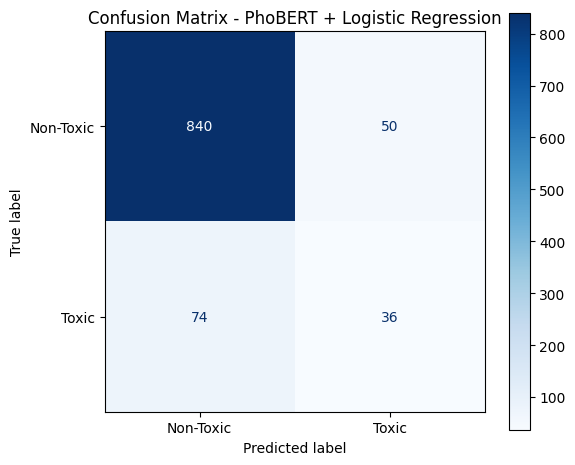

In [27]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    print(f"\n{'='*50}")
    print(f"KẾT QUẢ ĐÁNH GIÁ: {model_name}")
    print('='*50)

    # Classification Report
    print("\n📊 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Non-Toxic', 'Toxic']))

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=['Non-Toxic', 'Toxic'], ax=ax, cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

    # ROC-AUC nếu có probability
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        ap = average_precision_score(y_true, y_proba)
        print(f"\n🎯 ROC-AUC Score: {auc:.4f}")
        print(f"🎯 Average Precision: {ap:.4f}")

# Sử dụng các biến dự đoán đã có sẵn từ cell JgyecsOHMYWz
# Không cần load từ file pkl nếu file chưa tồn tại
try:
    # Nếu logreg_model chưa được định nghĩa, ta dùng biến 'model' từ cell huấn luyện Logistic
    # Lưu ý: Nếu bạn vừa chạy cell Fine-tune, biến 'model' có thể đã bị ghi đè.
    # Ở đây ta sử dụng lại kết quả dự đoán y_pred đã thực hiện ở bước Logistic Regression.
    y_proba_logreg = None
    if 'model' in globals() and hasattr(model, 'predict_proba'):
        y_proba_logreg = model.predict_proba(X_test_emb)[:, 1]

    evaluate_model(y_test, y_pred, y_proba_logreg, "PhoBERT + Logistic Regression")
except Exception as e:
    print(f"Có lỗi xảy ra khi đánh giá: {e}")
    print("Vui lòng đảm bảo bạn đã chạy cell huấn luyện Logistic Regression trước đó.")

3. Cross-Validation để đánh giá ổn định

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
cv_scores = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    X_train_emb, y_train,
    cv=cv, scoring='f1_weighted', n_jobs=-1
)

print(f"Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")


Cross-Validation F1 Scores: [0.81914322 0.82581351 0.81671383 0.80354279 0.83139115]
Mean F1: 0.8193 (+/- 0.0188)


4. Lưu và Tải Model

In [23]:
import joblib

# Lưu model
joblib.dump(model, '/content/drive/MyDrive/phobert_logreg_model.pkl')

# Lưu embeddings (để không phải chạy lại)
np.save('/content/drive/MyDrive/X_train_emb.npy', X_train_emb)
np.save('/content/drive/MyDrive/X_test_emb.npy', X_test_emb)

# Tải lại
model = joblib.load('/content/drive/MyDrive/phobert_logreg_model.pkl')
X_train_emb = np.load('/content/drive/MyDrive/X_train_emb.npy')


5. Hàm Dự đoán cho câu mới

In [24]:
import torch
from transformers import AutoModel
import joblib
import os

# 1. Đảm bảo lưu đúng mô hình Logistic Regression (chạy lại logic lưu nếu cần)
# Ở đây mình sẽ giả định lr_final là mô hình bạn muốn dùng
if 'lr_final' in globals():
    joblib.dump(lr_final, '/content/drive/MyDrive/phobert_logreg_model.pkl')

# 2. Tải lại mô hình từ file
final_ml_model = joblib.load('/content/drive/MyDrive/phobert_logreg_model.pkl')

# 3. Kiểm tra kiểu của mô hình để tránh lỗi cũ
if not hasattr(final_ml_model, 'predict'):
    print("CẢNH BÁO: Mô hình vừa tải không phải là Logistic Regression. Vui lòng chạy lại cell huấn luyện LR (JgyecsOHMYWz).")
else:
    # Đảm bảo có base model để tạo embedding
    phobert_base = AutoModel.from_pretrained("vinai/phobert-base").to('cuda')

    def predict_toxicity_ml(text, ml_model, tokenizer, embed_model):
        embed_model.eval()
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=128).to('cuda')

        with torch.no_grad():
            outputs = embed_model(**inputs)

        # Lấy vector CLS
        embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()

        # Dự đoán
        prediction = ml_model.predict(embedding)[0]
        probability = ml_model.predict_proba(embedding)[0]

        result = "🚨 ĐỘC HẠI" if prediction == 1 else "✅ KHÔNG ĐỘC HẠI"
        print(f"Văn bản: {text}")
        print(f"Kết quả: {result} ({probability[1]:.2%} toxic)")
        print("-" * 30)

    print("--- THỬ NGHIỆM DỰ ĐOÁN ---")
    predict_toxicity_ml("Bạn thật tuyệt vời!", final_ml_model, tokenizer, phobert_base)
    predict_toxicity_ml("Đồ ngu ngốc vô dụng!", final_ml_model, tokenizer, phobert_base)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--- THỬ NGHIỆM DỰ ĐOÁN ---
Văn bản: Bạn thật tuyệt vời!
Kết quả: ✅ KHÔNG ĐỘC HẠI (3.77% toxic)
------------------------------
Văn bản: Đồ ngu ngốc vô dụng!
Kết quả: 🚨 ĐỘC HẠI (98.34% toxic)
------------------------------


6. So sánh nhiều Model (Tổng hợp)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM': SVC(class_weight='balanced', probability=True, random_state=42),
    'MLP Neural Network': MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),
}

results = []
for name, clf in models.items():
    print(f"\n🔄 Đang huấn luyện {name}...")
    clf.fit(X_train_emb, y_train)
    y_pred = clf.predict(X_test_emb)

    from sklearn.metrics import f1_score, accuracy_score
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1 (Weighted)': f1_score(y_test, y_pred, average='weighted'),
        'F1 (Toxic)': f1_score(y_test, y_pred, pos_label=1)
    })

results_df = pd.DataFrame(results).sort_values('F1 (Weighted)', ascending=False)
print("\n" + "="*60)
print("📊 BẢNG SO SÁNH CÁC MÔ HÌNH")
print("="*60)
print(results_df.to_string(index=False))



🔄 Đang huấn luyện Logistic Regression...

🔄 Đang huấn luyện Random Forest...

🔄 Đang huấn luyện SVM...

🔄 Đang huấn luyện MLP Neural Network...

📊 BẢNG SO SÁNH CÁC MÔ HÌNH
              Model  Accuracy  F1 (Weighted)  F1 (Toxic)
 MLP Neural Network     0.876       0.869233    0.367347
                SVM     0.816       0.838412    0.414013
      Random Forest     0.890       0.838201    0.000000
Logistic Regression     0.786       0.817066    0.385057
